create SSP emissions 
1. Data before 2100 comes from iamc dataset
2. Data after 2100 comes from description in Paper: https://gmd.copernicus.org/articles/13/3571/2020/#section2
Here are the description:


'''
In summary, the extension principles are as follows:

From 2100 onwards, net negative fossil CO2 emissions are brought back to zero during the 22nd century, while positive fossil CO2 emissions are ramped down to zero by 2250.

Land use CO2 emissions are brought back to zero by 2150.

Non-CO2 fossil greenhouse gas emissions are ramped down to zero by 2250.

Land-use-related non-CO2 emissions are held constant at 2100 levels.

In the initial ScenarioMIP design (O'Neill et al., 2016), fossil CO2 emissions for SSP5-3.4-OS and SSP1-2.6 are negative at 2100 levels until 2140 and gradually increase to zero until 2190 and 2185, respectively (Fig. 2a). We did not assume permanent net-negative CO2 emissions to maintain proximity to the original scenario design in the light of biophysical and economic limits of negative emissions, as well as potential side effects (Fuss et al., 2018; Smith et al., 2016). For all scenarios with net negative fossil fuel extensions, we implemented extensions assuming constant emissions until 2140 (as suggested) but reaching zero emissions in 2190. The only exception is the SSP5-3.4-OS scenario, which was ramped back to zero by a slightly earlier date (2170) so that fossil and land use emissions (in combination with MAGICC7.0's default setting – see Sect. 2.4) met the design criteria of an approximate merge with SSP1-2.6 concentrations in the longer-term, i.e. after 2150.
'''''

总结：延伸原则如下：
从 2100 年起，化石燃料的净负二氧化碳排放在 22 世纪期间被回调至零，而正的化石燃料二氧化碳排放则逐步下降，至 2250 年降至零。

土地利用相关的二氧化碳排放至 2150 年被回调至零。

非二氧化碳的化石温室气体排放逐步下降，至 2250 年降至零。

土地利用相关的非二氧化碳排放保持 2100 年的水平不变。

在最初的 ScenarioMIP 设计中 (O'Neill et al., 2016)，SSP5-3.4-OS 和 SSP1-2.6 情景的化石二氧化碳排放在 2100 年保持净负值水平，直至 2140 年，随后分别逐渐增加到零，直至 2190 年和 2185 年（图 2a）。鉴于负排放的生物物理和经济限制以及潜在的副作用 (Fuss et al., 2018; Smith et al., 2016)，我们没有假设永久性的净负二氧化碳排放，以保持与原始情景设计的接近性。对于所有具有净负化石燃料延伸的情景，我们实施的延伸假设排放量保持恒定直到 2140 年（如建议），但在 2190 年达到零排放。唯一的例外是 SSP5-3.4-OS 情景，其回调至零的时间略早（2170 年），以便化石和土地利用排放（结合 MAGICC7.0 的默认设置——参见 2.4 节）满足设计标准，即在长期（即 2150 年之后）与 SSP1-2.6 浓度近似合并。

In [111]:
import pandas as pd
import numpy as np

# data 2000-2015
fhist='iamc_1990-2015.xlsx'

iamcH_data=pd.read_excel(fhist,header=None)
yearH = iamcH_data.iloc[0, :].to_numpy()
sspH = iamcH_data.iloc[1, :].to_numpy()
sspH=sspH*12.0/44000
print('yearH:',yearH)
print('sspH:',sspH)

# interpolate and interpolate to get annual data from 2000 to 2015
yearH_new = np.arange(2000, 2016, 1)
sspH_new = np.interp(yearH_new, yearH, sspH)
print('yearH_new:',yearH_new)
print('sspH_new:',sspH_new)

yearH: [1990. 1995. 2000. 2005. 2010. 2012. 2014. 2015.]
sspH: [ 7.6262367   7.85762506  8.0887305   9.11288084  9.85403923 10.35036135
 10.80764394 10.67801626]
yearH_new: [2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015]
sspH_new: [ 8.0887305   8.29356057  8.49839064  8.70322071  8.90805078  9.11288084
  9.26111252  9.4093442   9.55757588  9.70580756  9.85403923 10.10220029
 10.35036135 10.57900264 10.80764394 10.67801626]


In [112]:
# Read in data before 2100 
f2100='iamc_SSPs.xlsx'
#read in this xlsx 
import pandas as pd
iamc_data=pd.read_excel(f2100,header=None)
# print(iamc_data.head())
print('shape of iamc_data:',iamc_data.shape)
yearC = iamc_data.iloc[0, 1:].to_numpy().astype(int)

# ensure numeric dtype (fixes dtype('O') issues)
ssp5x85_2100 = iamc_data.iloc[9, 1:].to_numpy().astype(float)
ssp5x34_2100 = iamc_data.iloc[8, 1:].to_numpy().astype(float)
ssp4x60_2100 = iamc_data.iloc[4, 1:].to_numpy().astype(float)
ssp3x70_2100 = iamc_data.iloc[1, 1:].to_numpy().astype(float)
ssp2x45_2100 = iamc_data.iloc[7, 1:].to_numpy().astype(float)
ssp1x26_2100 = iamc_data.iloc[6, 1:].to_numpy().astype(float)
ssp1x19_2100 = iamc_data.iloc[5, 1:].to_numpy().astype(float)

# convert unit from Mt to Gtc
ssp5x85_2100=ssp5x85_2100*12.0/44000.0
ssp5x34_2100=ssp5x34_2100*12.0/44000.0
ssp4x60_2100=ssp4x60_2100*12.0/44000.0
ssp3x70_2100=ssp3x70_2100*12.0/44000.0
ssp2x45_2100=ssp2x45_2100*12.0/44000.0
ssp1x26_2100=ssp1x26_2100*12.0/44000.0
ssp1x19_2100=ssp1x19_2100*12.0/44000.0

print('yearC:',yearC)
print('ssp5x85_2100:',ssp5x85_2100)

# interpolate to get annual data from 2016 to 2100
yearC_new = np.arange(2016, 2101, 1).astype(int)
ssp5x85_2100_new = np.interp(yearC_new, yearC, ssp5x85_2100)
ssp5x34_2100_new = np.interp(yearC_new, yearC, ssp5x34_2100)
ssp4x60_2100_new = np.interp(yearC_new, yearC, ssp4x60_2100)
ssp3x70_2100_new = np.interp(yearC_new, yearC, ssp3x70_2100)
ssp2x45_2100_new = np.interp(yearC_new, yearC, ssp2x45_2100)
ssp1x26_2100_new = np.interp(yearC_new, yearC, ssp1x26_2100)
ssp1x19_2100_new = np.interp(yearC_new, yearC, ssp1x19_2100)

print('yearC_new:',yearC_new[-5:])


shape of iamc_data: (10, 11)
yearC: [2015 2020 2030 2040 2050 2060 2070 2080 2090 2100]
ssp5x85_2100: [10.67801626 11.92154961 15.08088633 18.7570086  22.71769635 27.36507441
 31.85597708 35.35828228 35.6117015  34.44199356]
yearC_new: [2096 2097 2098 2099 2100]


从 2100 年起，化石燃料的净负二氧化碳排放在 22 世纪期间被回调至零，而正的化石燃料二氧化碳排放则逐步下降，至 2250 年降至零。

土地利用相关的二氧化碳排放至 2150 年被回调至零。

SSP1-2.6 和 SSP1-1.9，延伸假设排放量保持恒定直到 2140 年，但在 2190 年达到零排放。

SSP5-3.4-OS 情景，延伸假设排放量保持恒定直到 2140 年，其回调至零的时间略早（2170 年）

In [113]:
# data at 2100. data source: https://tntcat.iiasa.ac.at/SspDb/dsd?Action=htmlpage&page=50
LandUseE=[-1530.317,-800.900,-1907.115,2656.121,-4800.077,-2899.036,-2381.434] # in Mt C/yr
LandUseE=np.array(LandUseE)*12.0/44000 # convert to Gtc/yr
AllE=[ssp5x85_2100_new[-1],ssp5x34_2100_new[-1],ssp4x60_2100_new[-1],ssp3x70_2100_new[-1],ssp2x45_2100_new[-1],ssp1x26_2100_new[-1],ssp1x19_2100_new[-1]] # in Gtc/yr   
FossilE=np.array(AllE)-np.array(LandUseE)
print('LandUseE Emission at 2100:',LandUseE)
print('FossilE Emission at 2100:',FossilE)

LandUseE Emission at 2100: [-0.41735918 -0.21842727 -0.52012227  0.72439664 -1.30911191 -0.79064618
 -0.649482  ]
FossilE Emission at 2100: [34.85935274 -5.32104054  6.49967046 21.83719421  3.94989158 -1.55965915
 -3.13864188]


In [114]:
# create files after 2100 according to extension principles

knowndata_years_Landuse=(2100,2150,2300)

knowndata_years_F_SSP534=(2100,2140,2170,2300)
knowndata_years_F_SSP1=(2100,2140,2190,2300)
knowndata_years_Fossil=(2100,2250,2300)

# write in known data first. These are from the extension principles
# 1. LandUse
ssp585_2300_Landuse_raw=(LandUseE[0],0.0,0.0)
ssp534_2300_Landuse_raw=(LandUseE[1],0.0,0.0)
ssp460_2300_Landuse_raw=(LandUseE[2],0.0,0.0)
ssp370_2300_Landuse_raw=(LandUseE[3],0.0,0.0)
ssp245_2300_Landuse_raw=(LandUseE[4],0.0,0.0)
ssp126_2300_Landuse_raw=(LandUseE[5],0.0,0.0)
ssp119_2300_Landuse_raw=(LandUseE[6],0.0,0.0)
# 2. Fossil
ssp585_2300_Fossil_raw=(FossilE[0],0.0,0.0)
ssp534_2300_Fossil_raw=(FossilE[1],FossilE[1],0.0,0.0)
ssp460_2300_Fossil_raw=(FossilE[2],0.0,0.0)
ssp370_2300_Fossil_raw=(FossilE[3],0.0,0.0)
ssp245_2300_Fossil_raw=(FossilE[4],0.0,0.0)
ssp126_2300_Fossil_raw=(FossilE[5],FossilE[5],0.0,0.0)
ssp119_2300_Fossil_raw=(FossilE[6],FossilE[6],0.0,0.0)

# Interpolate to get annual data from 2101 to 2300
year_Landuse_new = np.arange(2101, 2301, 1)
ssp585_2300_Landuse = np.interp(year_Landuse_new, knowndata_years_Landuse, ssp585_2300_Landuse_raw)
ssp534_2300_Landuse = np.interp(year_Landuse_new, knowndata_years_Landuse, ssp534_2300_Landuse_raw)
ssp460_2300_Landuse = np.interp(year_Landuse_new, knowndata_years_Landuse, ssp460_2300_Landuse_raw)
ssp370_2300_Landuse = np.interp(year_Landuse_new, knowndata_years_Landuse, ssp370_2300_Landuse_raw)
ssp245_2300_Landuse = np.interp(year_Landuse_new, knowndata_years_Landuse, ssp245_2300_Landuse_raw)
ssp126_2300_Landuse = np.interp(year_Landuse_new, knowndata_years_Landuse, ssp126_2300_Landuse_raw)
ssp119_2300_Landuse = np.interp(year_Landuse_new, knowndata_years_Landuse, ssp119_2300_Landuse_raw)     
year_Fossil_new = np.arange(2101, 2301, 1)
ssp585_2300_Fossil = np.interp(year_Fossil_new, knowndata_years_Fossil, ssp585_2300_Fossil_raw)
ssp534_2300_Fossil = np.interp(year_Fossil_new, knowndata_years_F_SSP534, ssp534_2300_Fossil_raw)
ssp460_2300_Fossil = np.interp(year_Fossil_new, knowndata_years_Fossil, ssp460_2300_Fossil_raw)
ssp370_2300_Fossil = np.interp(year_Fossil_new, knowndata_years_Fossil, ssp370_2300_Fossil_raw)
ssp245_2300_Fossil = np.interp(year_Fossil_new, knowndata_years_Fossil, ssp245_2300_Fossil_raw)
ssp126_2300_Fossil = np.interp(year_Fossil_new, knowndata_years_F_SSP1, ssp126_2300_Fossil_raw)
ssp119_2300_Fossil = np.interp(year_Fossil_new, knowndata_years_F_SSP1, ssp119_2300_Fossil_raw)    

ssp585_2300=ssp585_2300_Landuse+ssp585_2300_Fossil
ssp534_2300=ssp534_2300_Landuse+ssp534_2300_Fossil
ssp460_2300=ssp460_2300_Landuse+ssp460_2300_Fossil
ssp370_2300=ssp370_2300_Landuse+ssp370_2300_Fossil
ssp245_2300=ssp245_2300_Landuse+ssp245_2300_Fossil
ssp126_2300=ssp126_2300_Landuse+ssp126_2300_Fossil
ssp119_2300=ssp119_2300_Landuse+ssp119_2300_Fossil

print(year_Landuse_new[0:5])
print('ssp585 starts from 2100:',AllE[0],', and the following values:', ssp585_2300[0:5])



[2101 2102 2103 2104 2105]
ssp585 starts from 2100: 34.441993559842096 , and the following values: [34.21794506 33.99389656 33.76984806 33.54579955 33.32175105]


In [115]:
# conjecture full time series
year = np.arange(2000, 2301, 1)
year_full = np.concatenate((yearH_new, yearC_new, year_Landuse_new))
# use array comparison function to avoid ambiguous truth value
if not np.array_equal(year, year_full):
    raise ValueError('Error: year arrays do not match!')
    
ssp_585 = np.concatenate((sspH_new, ssp5x85_2100_new, ssp585_2300))
ssp_534 = np.concatenate((sspH_new, ssp5x34_2100_new, ssp534_2300))
ssp_460 = np.concatenate((sspH_new, ssp4x60_2100_new, ssp460_2300))
ssp_370 = np.concatenate((sspH_new, ssp3x70_2100_new, ssp370_2300))
ssp_245 = np.concatenate((sspH_new, ssp2x45_2100_new, ssp245_2300))
ssp_126 = np.concatenate((sspH_new, ssp1x26_2100_new, ssp126_2300))
ssp_119 = np.concatenate((sspH_new, ssp1x19_2100_new, ssp119_2300))


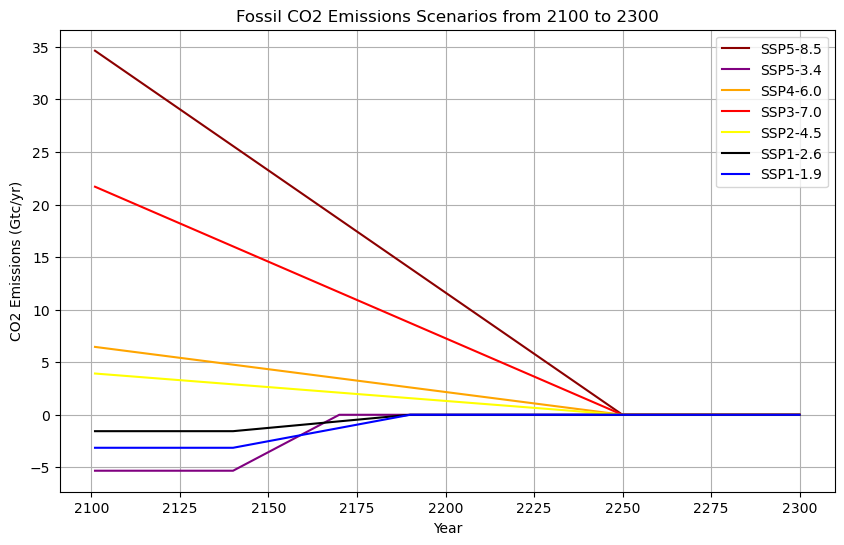

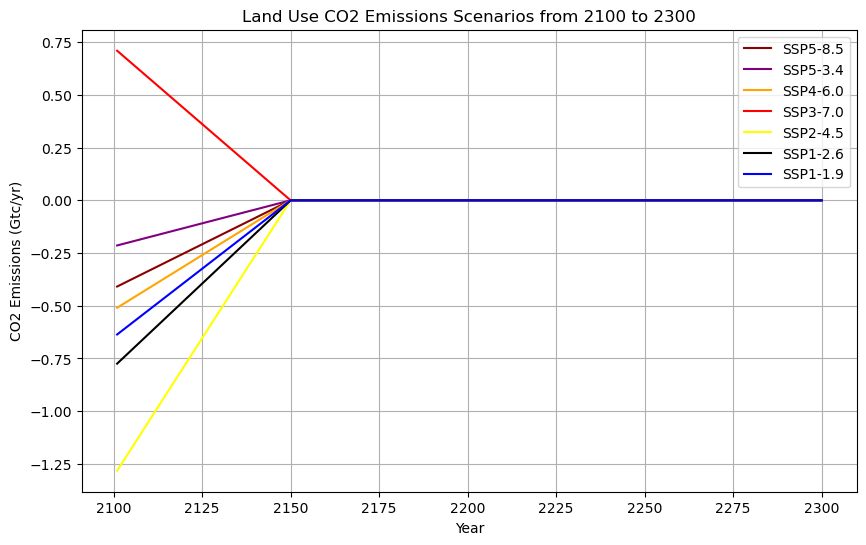

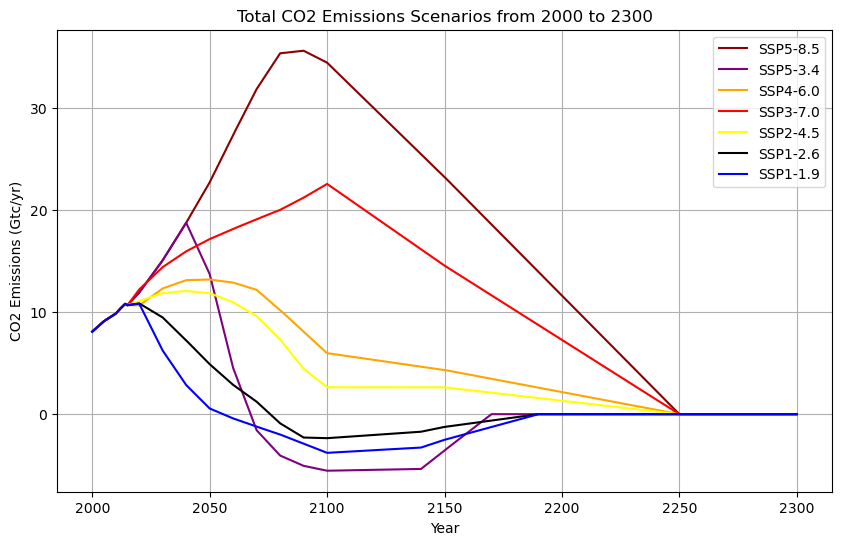

In [116]:
# Plotting to check
import matplotlib.pyplot as plt

# 1st fossil emission
plt.figure(figsize=(10,6))
plt.plot(year_Fossil_new, ssp585_2300_Fossil, label='SSP5-8.5',color='darkred')
plt.plot(year_Fossil_new, ssp534_2300_Fossil, label='SSP5-3.4',color='purple')
plt.plot(year_Fossil_new, ssp460_2300_Fossil, label='SSP4-6.0',color='orange')
plt.plot(year_Fossil_new, ssp370_2300_Fossil, label='SSP3-7.0',color='red')
plt.plot(year_Fossil_new, ssp245_2300_Fossil, label='SSP2-4.5',color='yellow')
plt.plot(year_Fossil_new, ssp126_2300_Fossil, label='SSP1-2.6',color='black')
plt.plot(year_Fossil_new, ssp119_2300_Fossil, label='SSP1-1.9',color='blue')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (Gtc/yr)')
plt.title('Fossil CO2 Emissions Scenarios from 2100 to 2300')
plt.legend()
plt.grid()
plt.show()

# 2nd Land use emission
plt.figure(figsize=(10,6))
plt.plot(year_Landuse_new, ssp585_2300_Landuse, label='SSP5-8.5',color='darkred')
plt.plot(year_Landuse_new, ssp534_2300_Landuse, label='SSP5-3.4',color='purple')
plt.plot(year_Landuse_new, ssp460_2300_Landuse, label='SSP4-6.0',color='orange')
plt.plot(year_Landuse_new, ssp370_2300_Landuse, label='SSP3-7.0',color='red')
plt.plot(year_Landuse_new, ssp245_2300_Landuse, label='SSP2-4.5',color='yellow')
plt.plot(year_Landuse_new, ssp126_2300_Landuse, label='SSP1-2.6',color='black')
plt.plot(year_Landuse_new, ssp119_2300_Landuse, label='SSP1-1.9',color='blue')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (Gtc/yr)')
plt.title('Land Use CO2 Emissions Scenarios from 2100 to 2300')
plt.legend()
plt.grid()
plt.show()

# 3rd total emission
plt.figure(figsize=(10,6))
plt.plot(year, ssp_585, label='SSP5-8.5',color='darkred')
plt.plot(year, ssp_534, label='SSP5-3.4',color='purple')
plt.plot(year, ssp_460, label='SSP4-6.0',color='orange')
plt.plot(year, ssp_370, label='SSP3-7.0',color='red')
plt.plot(year, ssp_245, label='SSP2-4.5',color='yellow')
plt.plot(year, ssp_126, label='SSP1-2.6',color='black')
plt.plot(year, ssp_119, label='SSP1-1.9',color='blue')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (Gtc/yr)')
plt.title('Total CO2 Emissions Scenarios from 2000 to 2300')
plt.legend()
plt.grid()
plt.show()


In [117]:
# save data and call it 'SSP_emissions_[scenario]_noPermafrost.txt'
np.savetxt('SSP_emissions_SSP5-8.5_noPermafrost.txt', np.column_stack((year, ssp_585)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='')
np.savetxt('SSP_emissions_SSP5-3.4_noPermafrost.txt', np.column_stack((year, ssp_534)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='')
np.savetxt('SSP_emissions_SSP4-6.0_noPermafrost.txt', np.column_stack((year, ssp_460)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='')
np.savetxt('SSP_emissions_SSP3-7.0_noPermafrost.txt', np.column_stack((year, ssp_370)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='')     
np.savetxt('SSP_emissions_SSP2-4.5_noPermafrost.txt', np.column_stack((year, ssp_245)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='')
np.savetxt('SSP_emissions_SSP1-2.6_noPermafrost.txt', np.column_stack((year, ssp_126)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='')
np.savetxt('SSP_emissions_SSP1-1.9_noPermafrost.txt', np.column_stack((year, ssp_119)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='')

# get the value of Permafrost emissions from 2000-2300

Data from AI 

Year	SSP585 SSP370 SSP370low SSP4-60 SSP2-45 SSP534	SSP1-26	 SSP1-1 SSP4-34
2000	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
2050	0.45	0.42	0.35	0.20	0.18	0.08	0.05	0.03	0.10
2100	2.20	1.80	1.35	1.05	0.80	0.40	0.30	0.20	0.35
2150	3.20	2.45	2.15	1.20	0.75	0.30	0.22	0.18	0.28
2200	2.20	1.85	1.50	1.00	0.65	0.28	0.21	0.17	0.25
2250	1.40	1.15	0.95	0.75	0.50	0.25	0.20	0.16	0.23
2300	1.00	0.85	0.70	0.60	0.40	0.22	0.18	0.15	0.20


In [118]:
import pandas as pd
import numpy as np
from scipy.ndimage import uniform_filter1d
# get the value of Permafrost emissions from 2000-2300
fPermaSSP585='SSP5-85_permafrost_raw.txt'
fPermaSSP534='SSP5-34_permafrost_raw.txt'
fPermaSSP460='SSP4-60_permafrost_raw.txt'
fPermaSSP370='SSP3-70_permafrost_raw.txt'
fPermaSSP245='SSP2-45_permafrost_raw.txt'
fPermaSSP126='SSP1-26_permafrost_raw.txt'
fPermaSSP119='SSP1-19_permafrost_raw.txt'

ssp585_Perma=pd.read_csv(fPermaSSP585,header=None,sep=',').iloc[:,1].to_numpy()
ssp534_Perma=pd.read_csv(fPermaSSP534,header=None,sep=',').iloc[:,1].to_numpy()
ssp460_Perma=pd.read_csv(fPermaSSP460,header=None,sep=',').iloc[:,1].to_numpy()
ssp370_Perma=pd.read_csv(fPermaSSP370,header=None,sep=',').iloc[:,1].to_numpy()
ssp245_Perma=pd.read_csv(fPermaSSP245,header=None,sep=',').iloc[:,1].to_numpy()
ssp126_Perma=pd.read_csv(fPermaSSP126,header=None,sep=',').iloc[:,1].to_numpy()
ssp119_Perma=pd.read_csv(fPermaSSP119,header=None,sep=',').iloc[:,1].to_numpy()


# do smoothing using moving average with window size 5
# Apply moving average smoothing with window size 5
ssp585_Perma = uniform_filter1d(ssp585_Perma, size=5, mode='nearest')
ssp534_Perma = uniform_filter1d(ssp534_Perma, size=5, mode='nearest')
ssp460_Perma = uniform_filter1d(ssp460_Perma, size=5, mode='nearest')
ssp370_Perma = uniform_filter1d(ssp370_Perma, size=5, mode='nearest')
ssp245_Perma = uniform_filter1d(ssp245_Perma, size=5, mode='nearest')
ssp126_Perma = uniform_filter1d(ssp126_Perma, size=5, mode='nearest')
ssp119_Perma = uniform_filter1d(ssp119_Perma, size=5, mode='nearest')

if not all([
    len(ssp585_Perma)==301,
    len(ssp534_Perma)==301,
    len(ssp460_Perma)==301,
    len(ssp370_Perma)==301,
    len(ssp245_Perma)==301,
    len(ssp126_Perma)==301,
    len(ssp119_Perma)==301
]):
    raise ValueError('Error: Permafrost data length is not 301!')

# calculate the accumulated emission at year 2100,2200 and 2300 for checking
accum_2100_585=np.trapz(ssp585_Perma[0:101])
accum_2200_585=np.trapz(ssp585_Perma[0:201])
accum_2300_585=np.trapz(ssp585_Perma[0:301])
print('Accumulated Permafrost Emissions SSP5-8.5 at 2100,2200,2300:',accum_2100_585,accum_2200_585,accum_2300_585)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 88, 378, 542 GtC respectively.')
accum_2100_534=np.trapz(ssp534_Perma[0:101])
accum_2200_534=np.trapz(ssp534_Perma[0:201])
accum_2300_534=np.trapz(ssp534_Perma[0:301])
print('Accumulated Permafrost Emissions SSP5-3.4 at 2100,2200,2300:',accum_2100_534,accum_2200_534,accum_2300_534)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 48, 83, 101 GtC respectively.')
accum_2100_460=np.trapz(ssp460_Perma[0:101])
accum_2200_460=np.trapz(ssp460_Perma[0:201])
accum_2300_460=np.trapz(ssp460_Perma[0:301])
print('Accumulated Permafrost Emissions SSP4-6.0 at 2100,2200,2300:',accum_2100_460,accum_2200_460,accum_2300_460)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 56, 167, 248 GtC respectively.')
accum_2100_370=np.trapz(ssp370_Perma[0:101])
accum_2200_370=np.trapz(ssp370_Perma[0:201])
accum_2300_370=np.trapz(ssp370_Perma[0:301])
print('Accumulated Permafrost Emissions SSP3-7.0 at 2100,2200,2300:',accum_2100_370,accum_2200_370,accum_2300_370)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 65, 288, 444 GtC respectively.')
accum_2100_245=np.trapz(ssp245_Perma[0:101])
accum_2200_245=np.trapz(ssp245_Perma[0:201])
accum_2300_245=np.trapz(ssp245_Perma[0:301])
print('Accumulated Permafrost Emissions SSP2-4.5 at 2100,2200,2300:',accum_2100_245,accum_2200_245,accum_2300_245)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 46, 121, 173 GtC respectively.')
accum_2100_126=np.trapz(ssp126_Perma[0:101])
accum_2200_126=np.trapz(ssp126_Perma[0:201])
accum_2300_126=np.trapz(ssp126_Perma[0:301])
print('Accumulated Permafrost Emissions SSP1-2.6 at 2100,2200,2300:',accum_2100_126,accum_2200_126,accum_2300_126)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 31, 58, 74 GtC respectively.')
accum_2100_119=np.trapz(ssp119_Perma[0:101])
accum_2200_119=np.trapz(ssp119_Perma[0:201])
accum_2300_119=np.trapz(ssp119_Perma[0:301])
print('Accumulated Permafrost Emissions SSP1-1.9 at 2100,2200,2300:',accum_2100_119,accum_2200_119,accum_2300_119)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 25, 42, 51 GtC respectively.')

# Fine tune data make it fits accumulated emission at target years
correction_2100_119=25.0 - accum_2100_119
ssp119_Perma[0:101]=ssp119_Perma[0:101]+correction_2100_119/100.0
correction_2200_119=42.0 - np.trapz(ssp119_Perma[0:201])
ssp119_Perma[101:201]=ssp119_Perma[101:201]+correction_2200_119/100.0
correction_2300_119=51.0 - np.trapz(ssp119_Perma[0:301])
ssp119_Perma[201:301]=ssp119_Perma[201:301]+correction_2300_119/100.0

correction_2100_126=31.0 - accum_2100_126
ssp126_Perma[0:101]=ssp126_Perma[0:101]+correction_2100_126/100.0
correction_2200_126=58.0 - np.trapz(ssp126_Perma[0:201])
ssp126_Perma[101:201]=ssp126_Perma[101:201]+correction_2200_126/100.0
correction_2300_126=74.0 - np.trapz(ssp126_Perma[0:301])
ssp126_Perma[201:301]=ssp126_Perma[201:301]+correction_2300_126/100.0

correction_2100_245=46.0 - accum_2100_245
ssp245_Perma[0:101]=ssp245_Perma[0:101]+correction_2100_245/100.0
correction_2200_245=121.0 - np.trapz(ssp245_Perma[0:201])
ssp245_Perma[101:201]=ssp245_Perma[101:201]+correction_2200_245/100.0
correction_2300_245=173.0 - np.trapz(ssp245_Perma[0:301])
ssp245_Perma[201:301]=ssp245_Perma[201:301]+correction_2300_245/100.0   

correction_2100_370=65.0 - accum_2100_370
ssp370_Perma[0:101]=ssp370_Perma[0:101]+correction_2100_370/100.0
correction_2200_370=288.0 - np.trapz(ssp370_Perma[0:201])
ssp370_Perma[101:201]=ssp370_Perma[101:201]+correction_2200_370/100.0
correction_2300_370=444.0 - np.trapz(ssp370_Perma[0:301])
ssp370_Perma[201:301]=ssp370_Perma[201:301]+correction_2300_370/100.0

correction_2100_460=56.0 - accum_2100_460
ssp460_Perma[0:101]=ssp460_Perma[0:101]+correction_2100_460/100.0
correction_2200_460=167.0 - np.trapz(ssp460_Perma[0:201])
ssp460_Perma[101:201]=ssp460_Perma[101:201]+correction_2200_460/100.0
correction_2300_460=248.0 - np.trapz(ssp460_Perma[0:301])
ssp460_Perma[201:301]=ssp460_Perma[201:301]+correction_2300_460/100.0

correction_2100_534=48.0 - accum_2100_534
ssp534_Perma[0:101]=ssp534_Perma[0:101]+correction_2100_534/100.0
correction_2200_534=83.0 - np.trapz(ssp534_Perma[0:201])
ssp534_Perma[101:201]=ssp534_Perma[101:201]+correction_2200_534/100.0
correction_2300_534=101.0 - np.trapz(ssp534_Perma[0:301])
ssp534_Perma[201:301]=ssp534_Perma[201:301]+correction_2300_534/100.0

correction_2100_585=88.0 - accum_2100_585
ssp585_Perma[0:101]=ssp585_Perma[0:101]+correction_2100_585/100.0
correction_2200_585=378.0 - np.trapz(ssp585_Perma[0:201])
ssp585_Perma[101:201]=ssp585_Perma[101:201]+correction_2200_585/100.0
correction_2300_585=542.0 - np.trapz(ssp585_Perma[0:301])
ssp585_Perma[201:301]=ssp585_Perma[201:301]+correction_2300_585/100.0


Accumulated Permafrost Emissions SSP5-8.5 at 2100,2200,2300: 88.04730000000002 378.1276000000001 541.7484999999999
Accumulated Permafrost Emission at 2100,2200,2300 should be: 88, 378, 542 GtC respectively.
Accumulated Permafrost Emissions SSP5-3.4 at 2100,2200,2300: 48.0403 83.16659999999999 101.02229999999994
Accumulated Permafrost Emission at 2100,2200,2300 should be: 48, 83, 101 GtC respectively.
Accumulated Permafrost Emissions SSP4-6.0 at 2100,2200,2300: 56.06479999999999 167.19000000000005 247.89270000000042
Accumulated Permafrost Emission at 2100,2200,2300 should be: 56, 167, 248 GtC respectively.
Accumulated Permafrost Emissions SSP3-7.0 at 2100,2200,2300: 66.4954 289.7930000000001 444.91290000000015
Accumulated Permafrost Emission at 2100,2200,2300 should be: 65, 288, 444 GtC respectively.
Accumulated Permafrost Emissions SSP2-4.5 at 2100,2200,2300: 46.3532 122.24730000000002 174.23410000000007
Accumulated Permafrost Emission at 2100,2200,2300 should be: 46, 121, 173 GtC resp

In [119]:
# calculate the accumulated emission at year 2100,2200 and 2300 for checking
accum_2100_585=np.trapz(ssp585_Perma[0:101])
accum_2200_585=np.trapz(ssp585_Perma[0:201])
accum_2300_585=np.trapz(ssp585_Perma[0:301])
print('Accumulated Permafrost Emissions SSP5-8.5 at 2100,2200,2300:',accum_2100_585,accum_2200_585,accum_2300_585)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 88, 378, 542 GtC respectively.')
accum_2100_534=np.trapz(ssp534_Perma[0:101])
accum_2200_534=np.trapz(ssp534_Perma[0:201])
accum_2300_534=np.trapz(ssp534_Perma[0:301])
print('Accumulated Permafrost Emissions SSP5-3.4 at 2100,2200,2300:',accum_2100_534,accum_2200_534,accum_2300_534)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 48, 83, 101 GtC respectively.')
accum_2100_460=np.trapz(ssp460_Perma[0:101])
accum_2200_460=np.trapz(ssp460_Perma[0:201])
accum_2300_460=np.trapz(ssp460_Perma[0:301])
print('Accumulated Permafrost Emissions SSP4-6.0 at 2100,2200,2300:',accum_2100_460,accum_2200_460,accum_2300_460)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 56, 167, 248 GtC respectively.')
accum_2100_370=np.trapz(ssp370_Perma[0:101])
accum_2200_370=np.trapz(ssp370_Perma[0:201])
accum_2300_370=np.trapz(ssp370_Perma[0:301])
print('Accumulated Permafrost Emissions SSP3-7.0 at 2100,2200,2300:',accum_2100_370,accum_2200_370,accum_2300_370)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 65, 288, 444 GtC respectively.')
accum_2100_245=np.trapz(ssp245_Perma[0:101])
accum_2200_245=np.trapz(ssp245_Perma[0:201])
accum_2300_245=np.trapz(ssp245_Perma[0:301])
print('Accumulated Permafrost Emissions SSP2-4.5 at 2100,2200,2300:',accum_2100_245,accum_2200_245,accum_2300_245)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 46, 121, 173 GtC respectively.')
accum_2100_126=np.trapz(ssp126_Perma[0:101])
accum_2200_126=np.trapz(ssp126_Perma[0:201])
accum_2300_126=np.trapz(ssp126_Perma[0:301])
print('Accumulated Permafrost Emissions SSP1-2.6 at 2100,2200,2300:',accum_2100_126,accum_2200_126,accum_2300_126)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 31, 58, 74 GtC respectively.')
accum_2100_119=np.trapz(ssp119_Perma[0:101])
accum_2200_119=np.trapz(ssp119_Perma[0:201])
accum_2300_119=np.trapz(ssp119_Perma[0:301])
print('Accumulated Permafrost Emissions SSP1-1.9 at 2100,2200,2300:',accum_2100_119,accum_2200_119,accum_2300_119)
print('Accumulated Permafrost Emission at 2100,2200,2300 should be: 25, 42, 51 GtC respectively.')

Accumulated Permafrost Emissions SSP5-8.5 at 2100,2200,2300: 88.0 378.00040031749995 541.9981045
Accumulated Permafrost Emission at 2100,2200,2300 should be: 88, 378, 542 GtC respectively.
Accumulated Permafrost Emissions SSP5-3.4 at 2100,2200,2300: 48.0 83.0006304925 100.9992785
Accumulated Permafrost Emission at 2100,2200,2300 should be: 48, 83, 101 GtC respectively.
Accumulated Permafrost Emissions SSP4-6.0 at 2100,2200,2300: 56.00000000000001 167.00062438 247.99851350000006
Accumulated Permafrost Emission at 2100,2200,2300 should be: 56, 167, 248 GtC respectively.
Accumulated Permafrost Emissions SSP3-7.0 at 2100,2200,2300: 65.0 288.001450615 443.9955995
Accumulated Permafrost Emission at 2100,2200,2300 should be: 65, 288, 444 GtC respectively.
Accumulated Permafrost Emissions SSP2-4.5 at 2100,2200,2300: 46.0 121.00446167 172.999934
Accumulated Permafrost Emission at 2100,2200,2300 should be: 46, 121, 173 GtC respectively.
Accumulated Permafrost Emissions SSP1-2.6 at 2100,2200,2300

In [120]:
# Extend Permafrost emissions to 2500 by linearly decreasing to zero from 2300 to 2500
year_Perma_new = np.arange(2301, 2501, 1)
ssp585_Perma_2500 = np.interp(year_Perma_new, [2300, 2500], [ssp585_Perma[300], 0.0])
ssp534_Perma_2500 = np.interp(year_Perma_new, [2300, 2500], [ssp534_Perma[300], 0.0])
ssp460_Perma_2500 = np.interp(year_Perma_new, [2300, 2500], [ssp460_Perma[300], 0.0])
ssp370_Perma_2500 = np.interp(year_Perma_new, [2300, 2500], [ssp370_Perma[300], 0.0])
ssp245_Perma_2500 = np.interp(year_Perma_new, [2300, 2500], [ssp245_Perma[300], 0.0])
ssp126_Perma_2500 = np.interp(year_Perma_new, [2300, 2500], [ssp126_Perma[300], 0.0])
ssp119_Perma_2500 = np.interp(year_Perma_new, [2300, 2500], [ssp119_Perma[300], 0.0])

ssp585_Perma_full = np.concatenate((ssp585_Perma, ssp585_Perma_2500))
ssp534_Perma_full = np.concatenate((ssp534_Perma, ssp534_Perma_2500))
ssp460_Perma_full = np.concatenate((ssp460_Perma, ssp460_Perma_2500))
ssp370_Perma_full = np.concatenate((ssp370_Perma, ssp370_Perma_2500))
ssp245_Perma_full = np.concatenate((ssp245_Perma, ssp245_Perma_2500))
ssp126_Perma_full = np.concatenate((ssp126_Perma, ssp126_Perma_2500))
ssp119_Perma_full = np.concatenate((ssp119_Perma, ssp119_Perma_2500))

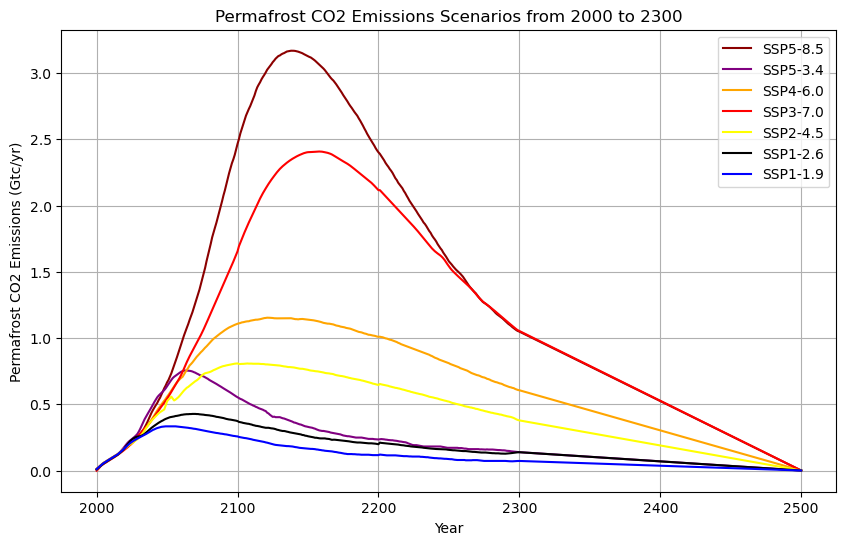

In [121]:
# plot permafrost emissions
import matplotlib.pyplot as plt
year_Perma_new = np.arange(2000, 2501, 1)
plt.figure(figsize=(10,6))
plt.plot(year_Perma_new, ssp585_Perma_full, label='SSP5-8.5',color='darkred')
plt.plot(year_Perma_new, ssp534_Perma_full, label='SSP5-3.4',color='purple')
plt.plot(year_Perma_new, ssp460_Perma_full, label='SSP4-6.0',color='orange')
plt.plot(year_Perma_new, ssp370_Perma_full, label='SSP3-7.0',color='red')
plt.plot(year_Perma_new, ssp245_Perma_full, label='SSP2-4.5',color='yellow')
plt.plot(year_Perma_new, ssp126_Perma_full, label='SSP1-2.6',color='black')
plt.plot(year_Perma_new, ssp119_Perma_full, label='SSP1-1.9',color='blue')
plt.xlabel('Year')
plt.ylabel('Permafrost CO2 Emissions (Gtc/yr)')
plt.title('Permafrost CO2 Emissions Scenarios from 2000 to 2300')
plt.legend()
plt.grid()
plt.show()  

In [122]:
# add another 200 years to year and total emissions arrays
year = np.arange(2000, 2501, 1)
ssp_585 = np.concatenate((ssp_585, np.zeros(200)))
ssp_534 =  np.concatenate((ssp_534, np.zeros(200)))
ssp_460 =  np.concatenate((ssp_460, np.zeros(200)))
ssp_370 =  np.concatenate((ssp_370, np.zeros(200)))
ssp_245 =  np.concatenate((ssp_245, np.zeros(200)))
ssp_126 =  np.concatenate((ssp_126, np.zeros(200)))
ssp_119 =  np.concatenate((ssp_119, np.zeros(200)))
# add permafrost emissions to previous total emissions and save new files
ssp_585_withPerma=ssp_585+ssp585_Perma_full
ssp_534_withPerma=ssp_534+ssp534_Perma_full
ssp_460_withPerma=ssp_460+ssp460_Perma_full
ssp_370_withPerma=ssp_370+ssp370_Perma_full
ssp_245_withPerma=ssp_245+ssp245_Perma_full
ssp_126_withPerma=ssp_126+ssp126_Perma_full
ssp_119_withPerma=ssp_119+ssp119_Perma_full

# save data and call it 'SSP_emissions_[scenario]_withPermafrost.txt'
np.savetxt('CO2_emissions_SSP5-85.txt', np.column_stack((year, ssp_585_withPerma)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='#%') 
np.savetxt('CO2_emissions_SSP5-34.txt', np.column_stack((year, ssp_534_withPerma)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='#%')
np.savetxt('CO2_emissions_SSP4-60.txt', np.column_stack((year, ssp_460_withPerma)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='#%') 
np.savetxt('CO2_emissions_SSP3-70.txt', np.column_stack((year, ssp_370_withPerma)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='#%')
np.savetxt('CO2_emissions_SSP2-45.txt', np.column_stack((year, ssp_245_withPerma)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='#%') 
np.savetxt('CO2_emissions_SSP1-26.txt', np.column_stack((year, ssp_126_withPerma)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='#%') 
np.savetxt('CO2_emissions_SSP1-19.txt', np.column_stack((year, ssp_119_withPerma)), fmt='%d %.6f', header='Year CO2_Emissions_Gtc_per_yr', comments='#%')

In [123]:
# get the total emissions including permafrost for checking
total_accum_585=np.trapz(ssp_585_withPerma)
total_accum_534=np.trapz(ssp_534_withPerma)
total_accum_460=np.trapz(ssp_460_withPerma)
total_accum_370=np.trapz(ssp_370_withPerma)
total_accum_245=np.trapz(ssp_245_withPerma)
total_accum_126=np.trapz(ssp_126_withPerma)
total_accum_119=np.trapz(ssp_119_withPerma)
print('Total Accumulated Emissions SSP5-8.5 from 2000 to 2500:',total_accum_585)
print('Total Accumulated Emissions SSP5-3.4 from 2000 to 2500:',total_accum_534)
print('Total Accumulated Emissions SSP4-6.0 from 2000 to 2500:',total_accum_460)
print('Total Accumulated Emissions SSP3-7.0 from 2000 to 2500:',total_accum_370)
print('Total Accumulated Emissions SSP2-4.5 from 2000 to 2500:',total_accum_245)
print('Total Accumulated Emissions SSP1-2.6 from 2000 to 2500:',total_accum_126)
print('Total Accumulated Emissions SSP1-1.9 from 2000 to 2500:',total_accum_119)

Total Accumulated Emissions SSP5-8.5 from 2000 to 2500: 5549.204141174261
Total Accumulated Emissions SSP5-3.4 from 2000 to 2500: 461.6533124343855
Total Accumulated Emissions SSP4-6.0 from 2000 to 2500: 1882.0937216894627
Total Accumulated Emissions SSP3-7.0 from 2000 to 2500: 3839.069952723064
Total Accumulated Emissions SSP2-4.5 from 2000 to 2500: 1421.1473173309819
Total Accumulated Emissions SSP1-2.6 from 2000 to 2500: 430.6680414657644
Total Accumulated Emissions SSP1-1.9 from 2000 to 2500: 100.79776096472912


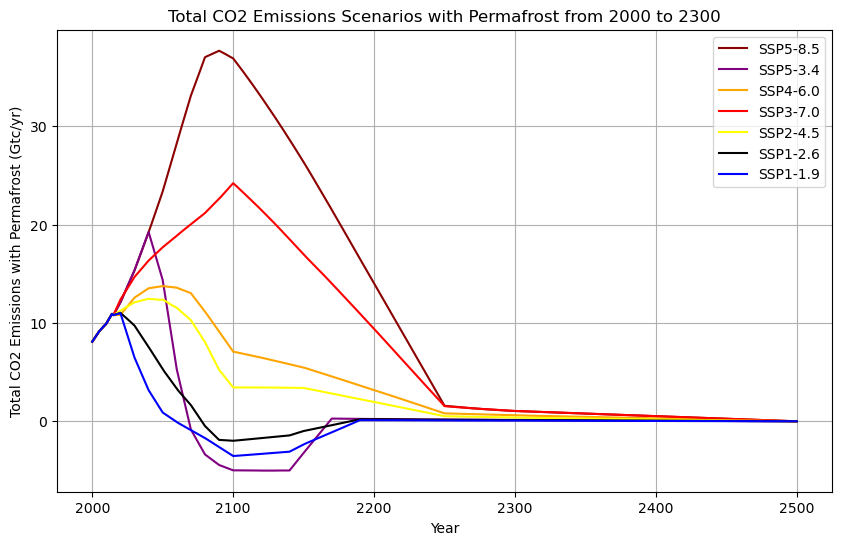

In [124]:
# Plotting to check total emissions with permafrost
plt.figure(figsize=(10,6))
plt.plot(year, ssp_585_withPerma, label='SSP5-8.5',color='darkred')
plt.plot(year, ssp_534_withPerma, label='SSP5-3.4',color='purple')
plt.plot(year, ssp_460_withPerma, label='SSP4-6.0',color='orange')  
plt.plot(year, ssp_370_withPerma, label='SSP3-7.0',color='red')
plt.plot(year, ssp_245_withPerma, label='SSP2-4.5',color='yellow')
plt.plot(year, ssp_126_withPerma, label='SSP1-2.6',color='black')
plt.plot(year, ssp_119_withPerma, label='SSP1-1.9',color='blue')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emissions with Permafrost (Gtc/yr)')
plt.title('Total CO2 Emissions Scenarios with Permafrost from 2000 to 2300')
plt.legend()
plt.grid()
plt.show()